# 1.4 SPOC source-data selection

Compare mechanism-aligned, substrate-similarity, ligand-similarity, and reaction-representation-similarity selection. Each strategy supplies 495 Ru-AHK reactions per target fold. Evaluate mixed transfer and delta learning with 10 regression algorithms.

PCA maps use the union of reactions selected across folds; selection frequencies are exported with the coordinates.


In [1]:
import hashlib
import json
import warnings
from collections import OrderedDict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pandas.errors import EmptyDataError

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        # Use the original font and export SVG glyphs as paths for consistent PPT rendering.
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "legend.fontsize": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "svg.fonttype": "path",
    }
)

SOURCE_RULE_COLORS = {
    "target_only": "#626262",                  # Scheme 1: Ru-AHO target
    "mechanism_aligned": "#278579",            # Scheme 1: aligned Ru-AHK
    "mechanism_mismatched": "#B56F61",         # Scheme 1: mismatched Ru-AHK
    "substrate_similar": "#628FBE",
    "ligand_similar": "#4C80B4",
    "reaction_representation_similar": "#285685",
}

# Parity and PCA only: True shows text/legends; False hides them.
# Heatmap and bar-chart text always remains visible. Axes and tick values remain.
SHOW_TEXT = False
SHOW_LEGEND = False

# Display order only: does not change source selection, fitting, or caches.
SOURCE_PLOT_ORDER = [
    "substrate_similar",
    "ligand_similar",
    "reaction_representation_similar",
    "mechanism_aligned",
]

# Mix source colors with white; 0 = base color, 1 = white.
PCA_SOURCE_LIGHTEN = 0.18
PCA_SOURCE_POINT_SIZE = 24
PCA_TARGET_POINT_SIZE = 30


def pca_source_color(rule_id):
    from matplotlib.colors import to_rgb
    rgb = np.asarray(to_rgb(SOURCE_RULE_COLORS[rule_id]))
    return tuple(rgb + (1.0 - rgb) * PCA_SOURCE_LIGHTEN)


def apply_figure_visibility(fig):
    """Hide annotations and axis titles while preserving axes and tick values."""
    if not SHOW_TEXT:
        for ax in fig.axes:
            ax.set_title("")
            ax.set_xlabel("")
            ax.set_ylabel("")
            for annotation in ax.texts:
                annotation.set_visible(False)
        for annotation in fig.texts:
            annotation.set_visible(False)
    if not SHOW_LEGEND:
        for legend in list(fig.legends):
            legend.remove()
        for ax in fig.axes:
            if ax.get_legend() is not None:
                ax.get_legend().remove()

# Keep the Figure 3 parity plots flatter for downstream layout.
FIGURE3_PARITY_FIGSIZE = (16.8, 3.4)
FIGURE3_PCA_FIGSIZE = (16.8, 3.4)

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, MACCSkeys
from rdkit.DataStructs import ConvertToNumpyArray

from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors
from sklearn.svm import SVR, LinearSVR
RDLogger.DisableLog("rdApp.warning")
from sklearn.decomposition import PCA
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
warnings.filterwarnings("ignore", category=ConvergenceWarning)
RDLogger.DisableLog("rdApp.warning")

RANDOM_STATE = 42
N_FOLDS = 5
MACCS_LENGTH = 167
TARGET_COLUMN = "ddG"
SIMILARITY_TARGET_TOP_K = 5
REACTION_SIM_GAMMA_MAX_POINTS = 1000

# Use the SPOC component order and construction from notebook 1.2.
COMPONENT_COLUMNS = [
    "Reactant SMILES",
    "Product SMILES",
    "Ligand SMILES",
    "Solvent SMILES",
    "Additive SMILES",
]
CONDITION_COLUMNS = ["Pressure/atm", "Temperature/C", "S/C"]
SIGNATURE_COLUMNS = [
    "Reactant SMILES",
    "Product SMILES",
    "Metal",
    "Ligand SMILES",
    "Solvent SMILES",
    "Additive SMILES",
    "Pressure/atm",
    "Temperature/C",
    "S/C",
]

# Feature and result caches are intentionally separated.
FORCE_RECOMPUTE_FEATURES = False
FORCE_RECOMPUTE_RESULTS = False


def find_project_root(start=None):
    """Find the repository root containing data/transfer and data/all_ahk_Ru."""
    start = Path.cwd() if start is None else Path(start)
    start = start.resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / "data" / "transfer").exists() and (candidate / "data" / "all_ahk_Ru").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TRANSFER_DIR = PROJECT_ROOT / "data" / "transfer"
ALL_AHK_RU_DIR = PROJECT_ROOT / "data" / "all_ahk_Ru"
OUT_DIR = PROJECT_ROOT / "results" / "1_4_spoc_source_domain_extension"
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR = OUT_DIR / "figures"
FEATURE_CACHE_DIR = OUT_DIR / "feature_cache"
for path in [TABLE_DIR, FIG_DIR, FEATURE_CACHE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Remove figures and figure-specific tables from older, more extensive versions.
for obsolete_figure in FIG_DIR.glob("*.svg"):
    obsolete_figure.unlink()

for obsolete_table_name in [
    "spoc_selected_transfer_delta_R2_model_by_source_rule.csv",
    "spoc_selected_transfer_absolute_R2_boxplot_data.csv",
    "spoc_fixed_model_parity_outcomes.csv",
]:
    obsolete_table = TABLE_DIR / obsolete_table_name
    if obsolete_table.exists():
        obsolete_table.unlink()

DATA_FILES = OrderedDict(
    [
        ("all_ru_ahk", ALL_AHK_RU_DIR / "processed_ahk_dataset_Ru.csv"),
        ("ru_ahk_inner", TRANSFER_DIR / "ru_ahk_inner.csv"),
        ("ru_ahk_outer", TRANSFER_DIR / "ru_ahk_outer.csv"),
        ("ru_aho_inner", TRANSFER_DIR / "ru_aho_inner.csv"),
    ]
)

INPUT_PIPELINE_ID = "spoc_compatible"
FEATURE_CACHE_PATH = FEATURE_CACHE_DIR / "spoc_compatible_combined_feature_matrix.npy"
OOF_PATH = TABLE_DIR / "spoc_compatible_source_selection_oof_predictions.csv"
CACHE_VERSION = "spoc_reaction_similarity_v2"
FEATURE_CACHE_META_PATH = FEATURE_CACHE_PATH.with_suffix(".meta.json")
OOF_CACHE_META_PATH = OOF_PATH.with_suffix(".meta.json")
SELECTION_AUDIT_PATH = TABLE_DIR / "spoc_source_selection_audit.csv"
SELECTION_MEMBERSHIP_PATH = TABLE_DIR / "spoc_source_selection_membership.csv"
METRICS_PATH = TABLE_DIR / "spoc_source_selection_pooled_metrics.csv"
BEST_METHOD_PATH = TABLE_DIR / "spoc_best_transfer_method_by_model_and_source_rule.csv"
BEST_SOURCE_PATH = TABLE_DIR / "spoc_best_model_method_by_source_rule.csv"
SUMMARY_PATH = TABLE_DIR / "spoc_best_method_source_rule_summary.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUT_DIR}")


Project root: /home/syz/ru-mechanism-transfer
Output directory: /home/syz/ru-mechanism-transfer/results/1_4_spoc_source_domain_extension


## 1. Load source candidates and target data

The complete processed Ru-AHK dataset supplies the candidate pool. The curated inner-sphere subset defines mechanism-aligned selection.


In [2]:
def _clean_string_series(series):
    return (
        series.fillna("")
        .astype(str)
        .str.strip()
        .replace({"nan": "", "None": "", "none": "", "null": ""})
    )


def canonicalize_smiles(value):
    """Use the same component-SMILES normalization as notebook 1.2."""
    if pd.isna(value):
        return ""
    smiles = str(value).strip()
    if smiles == "" or smiles.lower() in {"nan", "none", "null"}:
        return ""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return smiles
    try:
        return Chem.MolToSmiles(
            mol,
            canonical=True,
            isomericSmiles=True,
        )
    except Exception:
        return smiles


def _standardize_table(df, dataset_label):
    """Match notebook 1.2 input cleaning exactly for all modeled columns."""
    df = df.copy()
    required = [TARGET_COLUMN, "Reactant SMILES", "Product SMILES"]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"{dataset_label} is missing required columns: {missing}")

    df[TARGET_COLUMN] = pd.to_numeric(df[TARGET_COLUMN], errors="coerce")
    df = df.loc[df[TARGET_COLUMN].notna()].reset_index(drop=True)

    for col in COMPONENT_COLUMNS:
        if col not in df.columns:
            df[col] = ""
        df[col] = df[col].map(canonicalize_smiles)

    for col in CONDITION_COLUMNS:
        if col not in df.columns:
            df[col] = np.nan
        df[col] = pd.to_numeric(df[col], errors="coerce")

    if "Metal" not in df.columns:
        df["Metal"] = "Ru"
    df["Metal"] = (
        df["Metal"]
        .fillna("Ru")
        .astype(str)
        .str.strip()
        .str.capitalize()
    )

    if len(df) < 2:
        raise ValueError(f"{dataset_label} has too few valid rows after cleaning.")
    return df

def load_table(path, dataset_label):
    if not path.exists():
        raise FileNotFoundError(f"Cannot find {dataset_label}: {path}")
    return _standardize_table(pd.read_csv(path), dataset_label)


def normalized_numeric_text(value):
    try:
        number = float(value)
        if not np.isfinite(number):
            return ""
        return f"{number:.10g}"
    except Exception:
        return ""


def add_reaction_signature(df):
    """Add a stable signature for matching curated Ru rows back to all-AHK."""
    out = df.copy()
    parts = []
    for col in SIGNATURE_COLUMNS:
        if col in CONDITION_COLUMNS:
            part = out[col].map(normalized_numeric_text)
        else:
            part = _clean_string_series(out[col])
        parts.append(part)

    signature = parts[0]
    for part in parts[1:]:
        signature = signature.str.cat(part, sep="||")
    out["_reaction_signature"] = signature
    return out


def normalize_metal(value):
    text = str(value).strip()
    for symbol in ["Ru", "Rh", "Ir", "Co", "Fe", "Mn", "Ni", "Pd", "Pt"]:
        if symbol.lower() in text.lower():
            return symbol
    return text


def normalize_mechanism(value):
    text = str(value).strip().lower().replace("_", " ").replace("-", " ")
    text = " ".join(text.split())
    if text in {"inner", "inner sphere", "innersphere"}:
        return "inner"
    if text in {"outer", "outer sphere", "outersphere"}:
        return "outer"
    return ""


DATASETS = OrderedDict(
    (key, add_reaction_signature(load_table(path, key)))
    for key, path in DATA_FILES.items()
)

aligned_signatures = set(DATASETS["ru_ahk_inner"]["_reaction_signature"])
mismatched_signatures = set(DATASETS["ru_ahk_outer"]["_reaction_signature"])

all_ru_ahk = DATASETS["all_ru_ahk"].copy()
all_ru_ahk["_metal_std"] = all_ru_ahk["Metal"].map(normalize_metal)

non_ru_mask = ~all_ru_ahk["_metal_std"].eq("Ru")
if non_ru_mask.any():
    unexpected = sorted(all_ru_ahk.loc[non_ru_mask, "_metal_std"].unique().tolist())
    raise ValueError(
        "processed_ahk_dataset_Ru.csv must contain Ru records only. "
        f"Unexpected metal labels: {unexpected}"
    )

# Prefer the explicit mechanism label generated by notebook 0_1.
# Signature matching is retained only as a backward-compatible fallback.
if "Mechanism" in all_ru_ahk.columns:
    all_ru_ahk["_mechanism_std"] = all_ru_ahk["Mechanism"].map(normalize_mechanism)
    all_ru_ahk["_is_known_aligned"] = all_ru_ahk["_mechanism_std"].eq("inner")
    all_ru_ahk["_is_known_mismatched"] = all_ru_ahk["_mechanism_std"].eq("outer")
else:
    all_ru_ahk["_mechanism_std"] = ""
    all_ru_ahk["_is_known_aligned"] = all_ru_ahk["_reaction_signature"].isin(aligned_signatures)
    all_ru_ahk["_is_known_mismatched"] = all_ru_ahk["_reaction_signature"].isin(mismatched_signatures)

unassigned_mask = ~(
    all_ru_ahk["_is_known_aligned"] | all_ru_ahk["_is_known_mismatched"]
)
if unassigned_mask.any():
    raise ValueError(
        "The processed Ru-AHK pool contains rows without an inner/outer mechanism label: "
        f"{int(unassigned_mask.sum())} rows. Re-run notebook 0_1 and remove unlabelled rows."
    )

DATASETS["all_ru_ahk"] = all_ru_ahk


def metal_feature_label(value):
    """Return the normalized label used in the model's metal one-hot block."""
    label = str(normalize_metal(value)).strip()
    return label if label else "Unknown"


METAL_CATEGORIES = sorted(
    {
        metal_feature_label(value)
        for df in DATASETS.values()
        for value in df["Metal"].tolist()
    }
)
if not METAL_CATEGORIES:
    METAL_CATEGORIES = ["Unknown"]

METAL_TO_INDEX = {
    label: index
    for index, label in enumerate(METAL_CATEGORIES)
}
METAL_FEATURE_NAMES = [
    f"metal__{label}"
    for label in METAL_CATEGORIES
]

DATA_SUMMARY = pd.DataFrame(
    [
        {
            "dataset_key": key,
            "path": str(DATA_FILES[key].relative_to(PROJECT_ROOT)),
            "n_samples": len(df),
            "n_reactants": df["Reactant SMILES"].nunique(),
            "n_ligands": df["Ligand SMILES"].nunique(),
            "n_metals": df["Metal"].map(normalize_metal).nunique(),
            "n_inner": (
                int(df["_is_known_aligned"].sum())
                if "_is_known_aligned" in df.columns
                else (len(df) if key == "ru_ahk_inner" else 0)
            ),
            "n_outer": (
                int(df["_is_known_mismatched"].sum())
                if "_is_known_mismatched" in df.columns
                else (len(df) if key == "ru_ahk_outer" else 0)
            ),
            "ddG_mean": df[TARGET_COLUMN].mean(),
            "ddG_std": df[TARGET_COLUMN].std(),
        }
        for key, df in DATASETS.items()
    ]
)

display(DATA_SUMMARY)
print(f"Metal one-hot categories ({len(METAL_CATEGORIES)}): {METAL_CATEGORIES}")
print(
    "Processed Ru-AHK mechanism composition: "
    f"inner={int(all_ru_ahk['_is_known_aligned'].sum())}, "
    f"outer={int(all_ru_ahk['_is_known_mismatched'].sum())}, "
    f"total={len(all_ru_ahk)}"
)


,dataset_key,path,n_samples,n_reactants,n_ligands,n_metals,n_inner,n_outer,ddG_mean,ddG_std
0,all_ru_ahk,data/all_ahk_Ru/processed_ahk_dataset_Ru.csv,2034,527,345,1,495,1539,1.997207,0.890076
1,ru_ahk_inner,data/transfer/ru_ahk_inner.csv,495,214,41,1,495,0,2.077446,0.959506
2,ru_ahk_outer,data/transfer/ru_ahk_outer.csv,1539,345,304,1,0,1539,1.971399,0.865312
3,ru_aho_inner,data/transfer/ru_aho_inner.csv,98,38,22,1,0,0,1.910037,0.950583


Metal one-hot categories (1): ['Ru']
Processed Ru-AHK mechanism composition: inner=495, outer=1539, total=2034


## 2. Construct SPOC features

Use component MACCS fingerprints and RDKit descriptors, reaction conditions, and categorical encodings. Build a shared vocabulary across the candidate pool, source subsets, and target. Component MACCS blocks supply substrate and ligand similarity scores.


In [3]:
DESC_LIST = list(Descriptors._descList)
DESC_NAMES = [name for name, _ in DESC_LIST]
SPOC_DESCRIPTOR_VERSION = "spoc_official_like_compatible"

SPOC_COMPONENT_PREFIXES = OrderedDict(
    [
        ("Reactant SMILES", "reactant"),
        ("Product SMILES", "product"),
        ("Ligand SMILES", "ligand"),
        ("Solvent SMILES", "solvent"),
        ("Additive SMILES", "additive"),
    ]
)


def smiles_to_mol(smiles):
    if smiles is None or str(smiles).strip() == "":
        return None
    try:
        return Chem.MolFromSmiles(str(smiles))
    except Exception:
        return None


def maccs_array(mol):
    arr = np.zeros((MACCS_LENGTH,), dtype=np.float32)
    if mol is None:
        return arr
    try:
        fp = MACCSkeys.GenMACCSKeys(mol)
        ConvertToNumpyArray(fp, arr)
    except Exception:
        arr[:] = np.nan
    return arr


def rdkit_descriptor_array(mol):
    values = []
    for _, fn in DESC_LIST:
        if mol is None:
            values.append(np.nan)
            continue
        try:
            values.append(float(fn(mol)))
        except Exception:
            values.append(np.nan)
    return np.asarray(values, dtype=np.float32)


def build_component_spoc(df, col, prefix):
    maccs_rows = []
    descriptor_rows = []
    for smiles in df[col].astype(str).tolist():
        mol = smiles_to_mol(smiles)
        maccs_rows.append(maccs_array(mol))
        descriptor_rows.append(rdkit_descriptor_array(mol))

    maccs_df = pd.DataFrame(
        np.vstack(maccs_rows),
        columns=[f"{prefix}__MACCS_{i:03d}" for i in range(MACCS_LENGTH)],
        index=df.index,
    )
    descriptor_df = pd.DataFrame(
        np.vstack(descriptor_rows),
        columns=[f"{prefix}__RDKit_{name}" for name in DESC_NAMES],
        index=df.index,
    )
    return pd.concat([maccs_df, descriptor_df], axis=1)


def expected_spoc_feature_columns(df):
    columns = []
    for _, prefix in SPOC_COMPONENT_PREFIXES.items():
        columns.extend([f"{prefix}__MACCS_{i:03d}" for i in range(MACCS_LENGTH)])
        columns.extend([f"{prefix}__RDKit_{name}" for name in DESC_NAMES])

    columns.extend([f"condition__{col}" for col in CONDITION_COLUMNS])

    label_columns = pd.get_dummies(
        df[["Metal", "Solvent SMILES", "Additive SMILES"]]
        .fillna("Unknown")
        .astype(str),
        prefix=["label__Metal", "label__Solvent", "label__Additive"],
        dtype=np.float32,
    ).columns.astype(str).tolist()
    columns.extend(label_columns)
    return columns


def build_spoc_matrix(df):
    pieces = []
    for col, prefix in SPOC_COMPONENT_PREFIXES.items():
        print(f"Building SPOC component descriptors: {prefix}")
        pieces.append(build_component_spoc(df, col, prefix))

    condition_df = df[CONDITION_COLUMNS].apply(pd.to_numeric, errors="coerce")
    condition_df.columns = [f"condition__{col}" for col in condition_df.columns]
    pieces.append(condition_df)

    label_df = pd.get_dummies(
        df[["Metal", "Solvent SMILES", "Additive SMILES"]]
        .fillna("Unknown")
        .astype(str),
        prefix=["label__Metal", "label__Solvent", "label__Additive"],
        dtype=np.float32,
    )
    pieces.append(label_df)

    feature_df = pd.concat(pieces, axis=1).replace([np.inf, -np.inf], np.nan)
    return feature_df.to_numpy(dtype=np.float32), list(feature_df.columns)


def combined_slices():
    slices = OrderedDict()
    start = 0
    for key, df in DATASETS.items():
        stop = start + len(df)
        slices[key] = slice(start, stop)
        start = stop
    return slices


def load_cached_spoc_features(expected_columns):
    if FORCE_RECOMPUTE_FEATURES or not FEATURE_CACHE_PATH.exists():
        return None
    try:
        matrix = np.load(FEATURE_CACHE_PATH)
        expected_shape = (
            sum(len(df) for df in DATASETS.values()),
            len(expected_columns),
        )
        if matrix.shape != expected_shape:
            print(
                f"Cached SPOC matrix shape {matrix.shape} does not match "
                f"{expected_shape}; rebuilding."
            )
            return None
        slices = combined_slices()
        features = OrderedDict(
            (key, matrix[slices[key]].astype(np.float32, copy=False))
            for key in DATASETS
        )
        print(f"Loaded combined SPOC feature cache: {matrix.shape}")
        return features
    except Exception as exc:
        print(f"Could not load the SPOC feature cache: {exc!r}; rebuilding.")
        return None


def save_cached_spoc_features(features):
    matrix = np.vstack([features[key] for key in DATASETS]).astype(
        np.float32,
        copy=False,
    )
    np.save(FEATURE_CACHE_PATH, matrix)
    print(f"Saved combined SPOC feature matrix: {FEATURE_CACHE_PATH}  shape={matrix.shape}")


ALL_DF = pd.concat(
    [DATASETS[key] for key in DATASETS],
    ignore_index=True,
)
FEATURE_COLUMNS = expected_spoc_feature_columns(ALL_DF)

# The complete Ru-AHK pool is the exact union of the curated inner/outer domains.
# Duplicating those rows must not alter the feature vocabulary used by notebook 1.2.
PRIMARY_SCHEMA_DF = pd.concat(
    [
        DATASETS["ru_ahk_inner"],
        DATASETS["ru_ahk_outer"],
        DATASETS["ru_aho_inner"],
    ],
    ignore_index=True,
)
PRIMARY_FEATURE_COLUMNS = expected_spoc_feature_columns(PRIMARY_SCHEMA_DF)
if FEATURE_COLUMNS != PRIMARY_FEATURE_COLUMNS:
    extra_columns = sorted(set(FEATURE_COLUMNS) - set(PRIMARY_FEATURE_COLUMNS))
    missing_columns = sorted(set(PRIMARY_FEATURE_COLUMNS) - set(FEATURE_COLUMNS))
    raise RuntimeError(
        "The SPOC feature schema does not match notebook 1.2: "
        f"extra={extra_columns[:10]}, missing={missing_columns[:10]}."
    )
print(
    "Notebook 1.2-compatible SPOC feature schema confirmed: "
    f"{len(FEATURE_COLUMNS)} columns."
)
FEATURES = load_cached_spoc_features(FEATURE_COLUMNS)

if FEATURES is None:
    print(f"Building SPOC features for all benchmark tables: {len(ALL_DF)} rows")
    combined_matrix, built_columns = build_spoc_matrix(ALL_DF)
    if built_columns != FEATURE_COLUMNS:
        raise RuntimeError(
            "Reconstructed SPOC feature columns do not match the expected columns."
        )
    slices = combined_slices()
    FEATURES = OrderedDict(
        (key, combined_matrix[slices[key]].astype(np.float32, copy=False))
        for key in DATASETS
    )
    save_cached_spoc_features(FEATURES)

# Rebuild the three primary domains in exactly the same concatenation order as notebook 1.2.
# This prevents the auxiliary all-Ru-AHK pool from affecting the primary feature blocks.
PRIMARY_MATRIX, PRIMARY_BUILT_COLUMNS = build_spoc_matrix(PRIMARY_SCHEMA_DF)
if PRIMARY_BUILT_COLUMNS != PRIMARY_FEATURE_COLUMNS:
    raise RuntimeError("The primary SPOC feature reconstruction does not match notebook 1.2.")
primary_slices = OrderedDict()
primary_start = 0
for primary_key in ["ru_ahk_inner", "ru_ahk_outer", "ru_aho_inner"]:
    primary_stop = primary_start + len(DATASETS[primary_key])
    primary_slices[primary_key] = slice(primary_start, primary_stop)
    primary_start = primary_stop
for primary_key, primary_slice in primary_slices.items():
    FEATURES[primary_key] = PRIMARY_MATRIX[primary_slice].astype(np.float32, copy=False)
print("Primary SPOC feature blocks rebuilt with notebook 1.2 domain order.")
TARGETS = OrderedDict(
    (key, df[TARGET_COLUMN].to_numpy(dtype=float))
    for key, df in DATASETS.items()
)

# Reuse the component MACCS blocks embedded in SPOC for source selection.
COMPONENT_MACCS_INDICES = {}
for component_col, prefix in SPOC_COMPONENT_PREFIXES.items():
    indices = np.asarray(
        [
            idx
            for idx, feature_name in enumerate(FEATURE_COLUMNS)
            if feature_name.startswith(f"{prefix}__MACCS_")
        ],
        dtype=int,
    )
    if len(indices) != MACCS_LENGTH:
        raise RuntimeError(
            f"Expected {MACCS_LENGTH} MACCS columns for {component_col}, found {len(indices)}."
        )
    COMPONENT_MACCS_INDICES[component_col] = indices


def component_binary_features(dataset_key, component_col, indices=None):
    column_indices = COMPONENT_MACCS_INDICES[component_col]
    matrix = FEATURES[dataset_key][:, column_indices] > 0
    if indices is not None:
        matrix = matrix[np.asarray(indices, dtype=int)]
    return matrix.astype(np.uint8, copy=False)


print({key: value.shape for key, value in FEATURES.items()})
print(f"SPOC feature dimension: {len(FEATURE_COLUMNS)}")


Notebook 1.2-compatible SPOC feature schema confirmed: 2043 columns.
Building SPOC features for all benchmark tables: 4166 rows
Building SPOC component descriptors: reactant
Building SPOC component descriptors: product
Building SPOC component descriptors: ligand
Building SPOC component descriptors: solvent
Building SPOC component descriptors: additive
Saved combined SPOC feature matrix: /home/syz/ru-mechanism-transfer/results/1_4_spoc_source_domain_extension/feature_cache/spoc_compatible_combined_feature_matrix.npy  shape=(4166, 2043)
Building SPOC component descriptors: reactant
Building SPOC component descriptors: product
Building SPOC component descriptors: ligand
Building SPOC component descriptors: solvent
Building SPOC component descriptors: additive
Primary SPOC feature blocks rebuilt with notebook 1.2 domain order.
{'all_ru_ahk': (2034, 2043), 'ru_ahk_inner': (495, 2043), 'ru_ahk_outer': (1539, 2043), 'ru_aho_inner': (98, 2043)}
SPOC feature dimension: 2043


## 3. Source-selection rules

Use the complete inner-sphere source for mechanism-aligned selection. Rank the complete Ru-AHK pool against the target training fold for each similarity-based rule.


In [4]:
N_ALIGNED = len(DATASETS["ru_ahk_inner"])
N_MISMATCHED = len(DATASETS["ru_ahk_outer"])
SIMILARITY_SOURCE_N = N_ALIGNED

SOURCE_RULES = OrderedDict(
    [
        (
            "mechanism_aligned",
            {
                "label": "Mechanism aligned",
                "family": "Mechanistic",
                "dataset_key": "ru_ahk_inner",
                "selection": "fixed",
                "size_mode": "matched_reference",
                "description": (
                    "Complete curated Ru-AHK inner-sphere source domain."
                ),
            },
        ),
        (
            "substrate_similar",
            {
                "label": "Substrate similar",
                "family": "Similarity",
                "dataset_key": "all_ru_ahk",
                "selection": "similarity",
                "similarity_component": "substrate",
                "size_mode": "matched",
                "description": (
                    "Top-N processed Ru-AHK records by fold-local reactant "
                    "MACCS similarity."
                ),
            },
        ),
        (
            "ligand_similar",
            {
                "label": "Ligand similar",
                "family": "Similarity",
                "dataset_key": "all_ru_ahk",
                "selection": "similarity",
                "similarity_component": "ligand",
                "size_mode": "matched",
                "description": (
                    "Top-N processed Ru-AHK records by fold-local ligand "
                    "MACCS similarity."
                ),
            },
        ),
        (
            "reaction_representation_similar",
            {
                "label": "Reaction-representation similar",
                "family": "Similarity",
                "dataset_key": "all_ru_ahk",
                "selection": "similarity",
                "similarity_component": "reaction",
                "size_mode": "matched",
                "selection_variant": "reaction_repr_topk_rbf_similarity",
                "description": (
                    "Top-N processed Ru-AHK records by fold-local mean top-k "
                    "RBF similarity in the complete reaction representation."
                ),
            },
        ),
    ]
)

SOURCE_RULE_ORDER = list(SOURCE_RULES.keys())
SOURCE_RULE_TABLE = pd.DataFrame(
    [
        {
            "source_rule_id": rule_id,
            **rule,
        }
        for rule_id, rule in SOURCE_RULES.items()
    ]
)

print(f"Mechanism-aligned source size: {N_ALIGNED}")
print(f"All four source-selection strategies use N={SIMILARITY_SOURCE_N}")
display(SOURCE_RULE_TABLE)


Mechanism-aligned source size: 495
All four source-selection strategies use N=495


,source_rule_id,label,family,dataset_key,selection,size_mode,description,similarity_component,selection_variant
0,mechanism_aligned,Mechanism aligned,Mechanistic,ru_ahk_inner,fixed,matched_reference,Complete curated Ru-AHK inner-sphere source do...,NaN,NaN
1,substrate_similar,Substrate similar,Similarity,all_ru_ahk,similarity,matched,Top-N processed Ru-AHK records by fold-local r...,substrate,NaN
2,ligand_similar,Ligand similar,Similarity,all_ru_ahk,similarity,matched,Top-N processed Ru-AHK records by fold-local l...,ligand,NaN
3,reaction_representation_similar,Reaction-representation similar,Similarity,all_ru_ahk,similarity,matched,Top-N processed Ru-AHK records by fold-local m...,reaction,reaction_repr_topk_rbf_similarity


## 4. Select source reactions within each fold

Use the mean of the five highest MACCS Tanimoto similarities for substrate and ligand selection. Use the mean of the five highest RBF similarities after median imputation and standardization for reaction-representation selection. Select 495 reactions per rule. Target test reactions and selectivity labels do not enter the ranking.


In [5]:
def kfold_splits(y_target, split_seed=RANDOM_STATE):
    n_splits = min(N_FOLDS, len(y_target))
    if n_splits < 2:
        raise ValueError(
            "The Ru-AHO target domain has too few samples for OOF evaluation."
        )
    splitter = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=int(split_seed),
    )
    return list(splitter.split(np.zeros(len(y_target)), y_target))


TARGET_SPLITS = kfold_splits(TARGETS["ru_aho_inner"])


def topk_mean_tanimoto(
    source_bits,
    target_bits,
    top_k=SIMILARITY_TARGET_TOP_K,
    batch_size=1024,
):
    """Mean of each source row's top-k Tanimoto similarities."""
    source_bits = np.asarray(source_bits, dtype=np.uint8)
    target_bits = np.asarray(target_bits, dtype=np.uint8)

    if len(source_bits) == 0:
        return np.asarray([], dtype=float)
    if len(target_bits) == 0:
        return np.zeros(len(source_bits), dtype=float)

    target_int = target_bits.astype(np.int16, copy=False)
    target_sum = target_int.sum(axis=1)[None, :]
    k_eff = max(1, min(int(top_k), len(target_bits)))
    output = np.empty(len(source_bits), dtype=float)

    for start in range(0, len(source_bits), batch_size):
        stop = min(start + batch_size, len(source_bits))
        source_int = source_bits[start:stop].astype(
            np.int16,
            copy=False,
        )
        intersection = source_int @ target_int.T
        union = (
            source_int.sum(axis=1)[:, None]
            + target_sum
            - intersection
        )
        similarity = np.divide(
            intersection,
            union,
            out=np.zeros_like(intersection, dtype=float),
            where=union > 0,
        )
        top_values = np.partition(
            similarity,
            -k_eff,
            axis=1,
        )[:, -k_eff:]
        output[start:stop] = top_values.mean(axis=1)

    return output


def make_median_imputer():
    try:
        return SimpleImputer(
            strategy="median",
            keep_empty_features=True,
        )
    except TypeError:
        return SimpleImputer(strategy="median")


def deterministic_subsample(X, max_points, seed=RANDOM_STATE):
    X = np.asarray(X, dtype=np.float32)
    if len(X) <= int(max_points):
        return X
    rng = np.random.default_rng(int(seed))
    indices = rng.choice(
        len(X),
        size=int(max_points),
        replace=False,
    )
    return X[np.sort(indices)]


def shared_rbf_gamma(
    reference,
    max_points=REACTION_SIM_GAMMA_MAX_POINTS,
):
    """Median-heuristic RBF gamma for reaction-representation similarity."""
    reference = deterministic_subsample(
        reference,
        max_points=max_points,
        seed=RANDOM_STATE,
    )
    distances = pairwise_distances(
        reference,
        metric="euclidean",
    )
    values = distances[
        np.triu_indices_from(distances, k=1)
    ]
    values = values[
        np.isfinite(values)
        & (values > 0)
    ]
    if len(values) == 0:
        return 1.0
    median_distance = float(np.median(values))
    return 1.0 / (
        2.0 * median_distance**2
        + 1e-12
    )


def preprocess_reaction_similarity_space(
    source_matrix,
    target_train_matrix,
):
    """Fold-local pooled imputation and standardization for reaction similarity."""
    source_matrix = np.asarray(
        source_matrix,
        dtype=np.float32,
    )
    target_train_matrix = np.asarray(
        target_train_matrix,
        dtype=np.float32,
    )

    pooled = np.vstack(
        [source_matrix, target_train_matrix]
    )
    imputer = make_median_imputer()
    pooled = imputer.fit_transform(pooled)
    pooled = np.nan_to_num(
        pooled,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    scaler = StandardScaler()
    pooled = scaler.fit_transform(pooled)
    pooled = np.nan_to_num(
        pooled,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    ).astype(np.float32)

    n_source = len(source_matrix)
    return pooled[:n_source], pooled[n_source:]


def topk_mean_rbf_similarity(
    source_matrix,
    target_train_matrix,
    top_k=SIMILARITY_TARGET_TOP_K,
):
    """Mean of each source reaction's top-k RBF similarities to target training rows."""
    source_scaled, target_scaled = (
        preprocess_reaction_similarity_space(
            source_matrix,
            target_train_matrix,
        )
    )

    if len(source_scaled) == 0:
        return np.asarray([], dtype=float)
    if len(target_scaled) == 0:
        return np.zeros(len(source_scaled), dtype=float)

    gamma = shared_rbf_gamma(
        np.vstack([source_scaled, target_scaled])
    )
    similarities = rbf_kernel(
        source_scaled,
        target_scaled,
        gamma=gamma,
    )

    k_eff = max(
        1,
        min(int(top_k), len(target_scaled)),
    )
    top_values = np.partition(
        similarities,
        -k_eff,
        axis=1,
    )[:, -k_eff:]
    return top_values.mean(axis=1)


def candidate_indices_for_rule(rule):
    dataset_key = rule["dataset_key"]
    dataframe = DATASETS[dataset_key]
    mask = np.ones(len(dataframe), dtype=bool)

    if rule.get("metal_only", False):
        if dataset_key != "all_ru_ahk":
            raise ValueError(
                "metal_only is defined only for all_ru_ahk."
            )
        if "_metal_std" in dataframe.columns:
            mask &= dataframe[
                "_metal_std"
            ].eq("Ru").to_numpy()

    return np.flatnonzero(mask)


def mechanism_membership(
    dataset_key,
    selected_indices,
):
    selected_indices = np.asarray(
        selected_indices,
        dtype=int,
    )

    if dataset_key == "ru_ahk_inner":
        aligned = np.ones(
            len(selected_indices),
            dtype=bool,
        )
        mismatched = np.zeros(
            len(selected_indices),
            dtype=bool,
        )
    elif dataset_key == "ru_ahk_outer":
        aligned = np.zeros(
            len(selected_indices),
            dtype=bool,
        )
        mismatched = np.ones(
            len(selected_indices),
            dtype=bool,
        )
    elif dataset_key == "all_ru_ahk":
        dataframe = DATASETS[
            dataset_key
        ].iloc[selected_indices]
        aligned = dataframe[
            "_is_known_aligned"
        ].to_numpy(dtype=bool)
        mismatched = dataframe[
            "_is_known_mismatched"
        ].to_numpy(dtype=bool)
    else:
        aligned = np.zeros(
            len(selected_indices),
            dtype=bool,
        )
        mismatched = np.zeros(
            len(selected_indices),
            dtype=bool,
        )

    return aligned, mismatched


def source_similarity_scores(
    dataset_key,
    source_indices,
    target_train_indices,
):
    source_reactant = component_binary_features(
        dataset_key,
        "Reactant SMILES",
        source_indices,
    )
    source_ligand = component_binary_features(
        dataset_key,
        "Ligand SMILES",
        source_indices,
    )
    target_reactant = component_binary_features(
        "ru_aho_inner",
        "Reactant SMILES",
        target_train_indices,
    )
    target_ligand = component_binary_features(
        "ru_aho_inner",
        "Ligand SMILES",
        target_train_indices,
    )

    substrate_score = topk_mean_tanimoto(
        source_reactant,
        target_reactant,
    )
    ligand_score = topk_mean_tanimoto(
        source_ligand,
        target_ligand,
    )
    reaction_score = topk_mean_rbf_similarity(
        FEATURES[dataset_key][source_indices],
        FEATURES["ru_aho_inner"][
            target_train_indices
        ],
    )
    return substrate_score, ligand_score, reaction_score


def choose_source_indices(
    rule_id,
    fold_id,
    target_train_indices,
):
    rule = SOURCE_RULES[rule_id]
    candidate_indices = candidate_indices_for_rule(
        rule
    )

    if len(candidate_indices) < 2:
        raise ValueError(
            f"Rule {rule_id!r} has fewer than two candidate rows."
        )

    selection = rule["selection"]
    desired_n = (
        len(candidate_indices)
        if selection == "fixed"
        else min(
            SIMILARITY_SOURCE_N,
            len(candidate_indices),
        )
    )

    (
        substrate_score,
        ligand_score,
        reaction_score,
    ) = source_similarity_scores(
        rule["dataset_key"],
        candidate_indices,
        target_train_indices,
    )

    if selection == "fixed":
        selected_local = np.arange(
            len(candidate_indices),
            dtype=int,
        )
        selection_score = np.full(
            len(selected_local),
            np.nan,
            dtype=float,
        )
    elif selection == "similarity":
        component = rule["similarity_component"]
        score = {
            "substrate": substrate_score,
            "ligand": ligand_score,
            "reaction": reaction_score,
        }[component]
        ranked_local = np.lexsort(
            (
                candidate_indices,
                -score,
            )
        )
        selected_local = ranked_local[:desired_n]
        selection_score = score[selected_local]
    else:
        raise ValueError(
            f"Unknown selection type: {selection}"
        )

    selected_indices = candidate_indices[
        selected_local
    ]
    selected_substrate = substrate_score[
        selected_local
    ]
    selected_ligand = ligand_score[
        selected_local
    ]
    selected_reaction = reaction_score[
        selected_local
    ]

    aligned, mismatched = mechanism_membership(
        rule["dataset_key"],
        selected_indices,
    )

    index_hash = hashlib.sha1(
        (
            rule["dataset_key"]
            + ":"
            + ",".join(
                map(
                    str,
                    selected_indices.tolist(),
                )
            )
        ).encode("utf-8")
    ).hexdigest()[:16]

    audit = {
        "source_rule_id": rule_id,
        "source_label": rule["label"],
        "source_family": rule["family"],
        "selection_variant": rule.get(
            "selection_variant",
            rule_id,
        ),
        "fold_id": int(fold_id),
        "dataset_key": rule["dataset_key"],
        "selection": selection,
        "similarity_component": rule.get(
            "similarity_component",
            "",
        ),
        "similarity_top_k": (
            SIMILARITY_TARGET_TOP_K
            if selection == "similarity"
            else np.nan
        ),
        "n_candidates": int(
            len(candidate_indices)
        ),
        "n_source": int(
            len(selected_indices)
        ),
        "selected_index_hash": index_hash,
        "mean_substrate_similarity": float(
            np.mean(selected_substrate)
        ),
        "mean_ligand_similarity": float(
            np.mean(selected_ligand)
        ),
        "mean_reaction_similarity": float(
            np.mean(selected_reaction)
        ),
        "minimum_selected_score": (
            float(np.nanmin(selection_score))
            if np.isfinite(selection_score).any()
            else np.nan
        ),
        "maximum_selected_score": (
            float(np.nanmax(selection_score))
            if np.isfinite(selection_score).any()
            else np.nan
        ),
        "selection_uses_ddG": False,
        "held_out_target_used": False,
        "aligned_overlap_count": int(
            aligned.sum()
        ),
        "aligned_overlap_rate": (
            float(aligned.mean())
            if len(aligned)
            else np.nan
        ),
        "mismatched_overlap_count": int(
            mismatched.sum()
        ),
        "mismatched_overlap_rate": (
            float(mismatched.mean())
            if len(mismatched)
            else np.nan
        ),
        "unassigned_rate": (
            float(
                (
                    ~aligned
                    & ~mismatched
                ).mean()
            )
            if len(aligned)
            else np.nan
        ),
    }
    return (
        selected_indices,
        selection_score,
        audit,
    )


SOURCE_SELECTIONS = {}
audit_rows = []
membership_rows = []

for fold_id, (
    target_train_idx,
    target_test_idx,
) in enumerate(
    TARGET_SPLITS,
    start=1,
):
    for rule_id in SOURCE_RULE_ORDER:
        (
            selected_indices,
            selected_scores,
            audit,
        ) = choose_source_indices(
            rule_id,
            fold_id,
            target_train_idx,
        )
        SOURCE_SELECTIONS[
            (
                rule_id,
                fold_id,
            )
        ] = selected_indices
        audit_rows.append(audit)

        rule = SOURCE_RULES[rule_id]
        for selected_index, selected_score in zip(
            np.asarray(
                selected_indices,
                dtype=int,
            ),
            np.asarray(
                selected_scores,
                dtype=float,
            ),
        ):
            membership_rows.append(
                {
                    "source_rule_id": rule_id,
                    "source_label": rule["label"],
                    "source_family": rule["family"],
                    "selection_variant": rule.get(
                        "selection_variant",
                        rule_id,
                    ),
                    "fold_id": int(fold_id),
                    "dataset_key": rule["dataset_key"],
                    "selected_index": int(
                        selected_index
                    ),
                    "selection_score": (
                        float(selected_score)
                        if np.isfinite(
                            selected_score
                        )
                        else np.nan
                    ),
                    "selection_uses_ddG": False,
                    "held_out_target_used": False,
                }
            )


SOURCE_SELECTION_AUDIT = pd.DataFrame(
    audit_rows
)
SOURCE_SELECTION_MEMBERSHIP = pd.DataFrame(
    membership_rows
)

SOURCE_SELECTION_AUDIT.to_csv(
    SELECTION_AUDIT_PATH,
    index=False,
)
SOURCE_SELECTION_MEMBERSHIP.to_csv(
    SELECTION_MEMBERSHIP_PATH,
    index=False,
)

print(
    "Saved fold-local source membership:",
    SELECTION_MEMBERSHIP_PATH.relative_to(
        PROJECT_ROOT
    ),
    SOURCE_SELECTION_MEMBERSHIP.shape,
)

display(
    SOURCE_SELECTION_AUDIT.groupby(
        [
            "source_rule_id",
            "source_label",
            "source_family",
            "selection_variant",
        ],
        as_index=False,
    ).agg(
        n_source_mean=(
            "n_source",
            "mean",
        ),
        substrate_similarity_mean=(
            "mean_substrate_similarity",
            "mean",
        ),
        ligand_similarity_mean=(
            "mean_ligand_similarity",
            "mean",
        ),
        reaction_similarity_mean=(
            "mean_reaction_similarity",
            "mean",
        ),
        aligned_overlap_rate=(
            "aligned_overlap_rate",
            "mean",
        ),
        mismatched_overlap_rate=(
            "mismatched_overlap_rate",
            "mean",
        ),
    )
)

if SOURCE_SELECTION_AUDIT[
    "selection_uses_ddG"
].any():
    raise AssertionError(
        "Source selection must not use ddG."
    )
if SOURCE_SELECTION_AUDIT[
    "held_out_target_used"
].any():
    raise AssertionError(
        "Source selection must not use held-out target rows."
    )



Saved fold-local source membership: results/1_4_spoc_source_domain_extension/tables/spoc_source_selection_membership.csv (9900, 10)


,source_rule_id,source_label,source_family,selection_variant,n_source_mean,substrate_similarity_mean,ligand_similarity_mean,reaction_similarity_mean,aligned_overlap_rate,mismatched_overlap_rate
0,ligand_similar,Ligand similar,Similarity,ligand_similar,495.0,0.384768,0.763842,0.604677,0.640000,0.360000
1,mechanism_aligned,Mechanism aligned,Mechanistic,mechanism_aligned,495.0,0.402166,0.684123,0.703519,1.000000,0.000000
2,reaction_representation_similar,Reaction-representation similar,Similarity,reaction_repr_topk_rbf_similarity,495.0,0.417858,0.504409,0.738005,0.144242,0.855758
3,substrate_similar,Substrate similar,Similarity,substrate_similar,495.0,0.500642,0.526822,0.646510,0.316768,0.683232


## 5. Train and evaluate models

Use the regression algorithms and preprocessing of notebook 1.2. For fold-specific source selections, fit the source model within each fold. Evaluate mixed transfer and delta learning separately.


In [6]:
SPOC_MODEL_FACTORIES = OrderedDict(
    [
        (
            "ExtraTreesRegressor",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                ExtraTreesRegressor(n_jobs=-1, random_state=RANDOM_STATE),
            ),
        ),
        (
            "GradientBoostingRegressor",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                GradientBoostingRegressor(random_state=RANDOM_STATE),
            ),
        ),
        (
            "HistGradientBoostingRegressor",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                HistGradientBoostingRegressor(random_state=RANDOM_STATE),
            ),
        ),
        (
            "RandomForestRegressor",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE),
            ),
        ),
        (
            "GaussianProcessRegressor",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                StandardScaler(),
                GaussianProcessRegressor(
                    normalize_y=True,
                    alpha=1e-6,
                    random_state=RANDOM_STATE,
                ),
            ),
        ),
        (
            "KNeighborsRegressor",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                StandardScaler(),
                KNeighborsRegressor(),
            ),
        ),
        (
            "SVR",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                StandardScaler(),
                SVR(),
            ),
        ),
        (
            "LinearSVR",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                StandardScaler(),
                LinearSVR(random_state=RANDOM_STATE, max_iter=5000),
            ),
        ),
        (
            "DecisionTreeRegressor",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                DecisionTreeRegressor(random_state=RANDOM_STATE),
            ),
        ),
        (
            "ExtraTreeRegressor",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                ExtraTreeRegressor(random_state=RANDOM_STATE),
            ),
        ),
    ]
)
MODEL_KEYS_TO_RUN = list(SPOC_MODEL_FACTORIES.keys())

MODEL_AUDIT_DF = pd.DataFrame(
    [
        {
            "model": model_key,
            "factory_repr": repr(SPOC_MODEL_FACTORIES[model_key]()),
        }
        for model_key in MODEL_KEYS_TO_RUN
    ]
)
display(MODEL_AUDIT_DF)


def make_model(model_key):
    return SPOC_MODEL_FACTORIES[model_key]()


def predict_1d(model, x):
    return np.asarray(model.predict(x)).reshape(-1).astype(float)


OOF_COLUMNS = [
    "model",
    "source_rule_id",
    "source_label",
    "source_family",
    "method_label",
    "fold_id",
    "target_index",
    "n_source",
    "aligned_overlap_rate",
    "mismatched_overlap_rate",
    "y_true",
    "y_pred",
]


def read_csv_or_empty(path, columns):
    path = Path(path)
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame(columns=columns)
    try:
        return pd.read_csv(path)
    except EmptyDataError:
        return pd.DataFrame(columns=columns)


def oof_cache_is_compatible(path):
    if FORCE_RECOMPUTE_RESULTS:
        return False
    cached = read_csv_or_empty(path, OOF_COLUMNS)
    if len(cached) == 0 or not set(OOF_COLUMNS).issubset(cached.columns):
        return False

    expected = {(model, "target_only", "Target-only") for model in MODEL_KEYS_TO_RUN}
    for model in MODEL_KEYS_TO_RUN:
        for rule_id in SOURCE_RULE_ORDER:
            for method in ["Mixed transfer", "Delta learning"]:
                expected.add((model, rule_id, method))
    observed = set(
        cached[["model", "source_rule_id", "method_label"]]
        .drop_duplicates()
        .itertuples(index=False, name=None)
    )
    if expected != observed:
        return False

    n_target = len(DATASETS["ru_aho_inner"])
    counts = cached.groupby(
        ["model", "source_rule_id", "method_label"]
    )["target_index"].nunique()
    return bool((counts == n_target).all())


def run_target_only_oof(model_key):
    x_target = FEATURES["ru_aho_inner"]
    y_target = TARGETS["ru_aho_inner"]
    rows = []
    for fold_id, (train_idx, test_idx) in enumerate(TARGET_SPLITS, start=1):
        model = make_model(model_key)
        model.fit(x_target[train_idx], y_target[train_idx])
        pred = predict_1d(model, x_target[test_idx])
        for target_index, truth, pred_value in zip(
            test_idx,
            y_target[test_idx],
            pred,
        ):
            rows.append(
                {
                    "model": model_key,
                    "source_rule_id": "target_only",
                    "source_label": "Target-only",
                    "source_family": "Baseline",
                    "method_label": "Target-only",
                    "fold_id": int(fold_id),
                    "target_index": int(target_index),
                    "n_source": 0,
                    "aligned_overlap_rate": np.nan,
                    "mismatched_overlap_rate": np.nan,
                    "y_true": float(truth),
                    "y_pred": float(pred_value),
                }
            )
    return rows


def run_transfer_rule_oof(model_key, rule_id):
    rule = SOURCE_RULES[rule_id]
    dataset_key = rule["dataset_key"]
    x_target = FEATURES["ru_aho_inner"]
    y_target = TARGETS["ru_aho_inner"]
    rows = []

    audit_lookup = SOURCE_SELECTION_AUDIT.loc[
        SOURCE_SELECTION_AUDIT["source_rule_id"].eq(rule_id)
    ].set_index("fold_id")

    for fold_id, (train_idx, test_idx) in enumerate(TARGET_SPLITS, start=1):
        selected_indices = SOURCE_SELECTIONS[(rule_id, fold_id)]
        x_source = FEATURES[dataset_key][selected_indices]
        y_source = TARGETS[dataset_key][selected_indices]
        x_train = x_target[train_idx]
        y_train = y_target[train_idx]
        x_test = x_target[test_idx]
        y_test = y_target[test_idx]

        source_prior = make_model(model_key)
        source_prior.fit(x_source, y_source)

        mixed_model = make_model(model_key)
        mixed_model.fit(
            np.vstack([x_source, x_train]),
            np.concatenate([y_source, y_train]),
        )
        pred_mixed = predict_1d(mixed_model, x_test)

        delta_model = make_model(model_key)
        source_prior_train = predict_1d(source_prior, x_train)
        delta_model.fit(x_train, y_train - source_prior_train)
        pred_delta = predict_1d(source_prior, x_test) + predict_1d(
            delta_model,
            x_test,
        )

        audit = audit_lookup.loc[fold_id]
        for method_label, pred in [
            ("Mixed transfer", pred_mixed),
            ("Delta learning", pred_delta),
        ]:
            for target_index, truth, pred_value in zip(test_idx, y_test, pred):
                rows.append(
                    {
                        "model": model_key,
                        "source_rule_id": rule_id,
                        "source_label": rule["label"],
                        "source_family": rule["family"],
                        "method_label": method_label,
                        "fold_id": int(fold_id),
                        "target_index": int(target_index),
                        "n_source": int(audit["n_source"]),
                        "aligned_overlap_rate": float(
                            audit["aligned_overlap_rate"]
                        ),
                        "mismatched_overlap_rate": float(
                            audit["mismatched_overlap_rate"]
                        ),
                        "y_true": float(truth),
                        "y_pred": float(pred_value),
                    }
                )
    return rows


if oof_cache_is_compatible(OOF_PATH):
    OOF_DF = pd.read_csv(OOF_PATH)
    ERROR_DF = pd.DataFrame(columns=["model", "source_rule_id", "error"])
    print(f"Loaded compatible OOF predictions from {OOF_PATH}")
else:
    rows = []
    errors = []
    for model_key in MODEL_KEYS_TO_RUN:
        print(f"Running target-only baseline: {model_key}")
        try:
            rows.extend(run_target_only_oof(model_key))
        except Exception as exc:
            errors.append(
                {
                    "model": model_key,
                    "source_rule_id": "target_only",
                    "error": repr(exc),
                }
            )
            print(f"  Failed: {exc!r}")

        for rule_id in SOURCE_RULE_ORDER:
            print(f"Running {model_key}: {rule_id}")
            try:
                rows.extend(run_transfer_rule_oof(model_key, rule_id))
            except Exception as exc:
                errors.append(
                    {
                        "model": model_key,
                        "source_rule_id": rule_id,
                        "error": repr(exc),
                    }
                )
                print(f"  Failed: {exc!r}")

    OOF_DF = pd.DataFrame(rows, columns=OOF_COLUMNS)
    ERROR_DF = pd.DataFrame(errors)
    OOF_DF.to_csv(OOF_PATH, index=False)

print(f"OOF prediction rows: {len(OOF_DF)}")
if len(ERROR_DF):
    print("Some model-rule combinations failed:")
    display(ERROR_DF)


# No primary-notebook prediction comparison is performed here.
# The extension reports its own OOF metrics; input-pipeline consistency
# is enforced by the shared preprocessing and feature-construction code.
# No cross-notebook prediction audit is executed in the main workflow.


,model,factory_repr
0,ExtraTreesRegressor,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
1,GradientBoostingRegressor,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
2,HistGradientBoostingRegressor,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
3,RandomForestRegressor,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
4,GaussianProcessRegressor,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
5,KNeighborsRegressor,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
6,SVR,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
7,LinearSVR,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
8,DecisionTreeRegressor,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
9,ExtraTreeRegressor,"Pipeline(steps=[('simpleimputer', SimpleImpute..."


Running target-only baseline: ExtraTreesRegressor
Running ExtraTreesRegressor: mechanism_aligned
Running ExtraTreesRegressor: substrate_similar
Running ExtraTreesRegressor: ligand_similar
Running ExtraTreesRegressor: reaction_representation_similar
Running target-only baseline: GradientBoostingRegressor
Running GradientBoostingRegressor: mechanism_aligned
Running GradientBoostingRegressor: substrate_similar
Running GradientBoostingRegressor: ligand_similar
Running GradientBoostingRegressor: reaction_representation_similar
Running target-only baseline: HistGradientBoostingRegressor
Running HistGradientBoostingRegressor: mechanism_aligned
Running HistGradientBoostingRegressor: substrate_similar
Running HistGradientBoostingRegressor: ligand_similar
Running HistGradientBoostingRegressor: reaction_representation_similar
Running target-only baseline: RandomForestRegressor
Running RandomForestRegressor: mechanism_aligned
Running RandomForestRegressor: substrate_similar
Running RandomForestReg

## 6. Summarize pooled OOF metrics

For each algorithm and source-selection rule, select the transfer method with the higher pooled OOF R²; use lower MAE and then lower RMSE for ties. Export metrics for both methods.


In [7]:
def pooled_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    finite = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[finite]
    y_pred = y_pred[finite]
    return {
        "R2": float(r2_score(y_true, y_pred)) if len(y_true) >= 2 else np.nan,
        "MAE": float(mean_absolute_error(y_true, y_pred)) if len(y_true) else np.nan,
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))) if len(y_true) else np.nan,
        "n_test_total": int(len(y_true)),
    }


GROUP_COLUMNS = [
    "model",
    "source_rule_id",
    "source_label",
    "source_family",
    "method_label",
]

metric_rows = []
for keys, group in OOF_DF.groupby(GROUP_COLUMNS, dropna=False):
    row = dict(zip(GROUP_COLUMNS, keys))
    row.update(pooled_metrics(group["y_true"], group["y_pred"]))
    row["n_source_mean"] = float(group["n_source"].mean())
    row["aligned_overlap_rate_mean"] = (
        float(group["aligned_overlap_rate"].mean())
        if group["aligned_overlap_rate"].notna().any()
        else np.nan
    )
    row["mismatched_overlap_rate_mean"] = (
        float(group["mismatched_overlap_rate"].mean())
        if group["mismatched_overlap_rate"].notna().any()
        else np.nan
    )
    metric_rows.append(row)

METRICS_DF = pd.DataFrame(metric_rows)
BASELINE_METRICS = (
    METRICS_DF.loc[
        METRICS_DF["source_rule_id"].eq("target_only"),
        ["model", "R2", "MAE", "RMSE"],
    ]
    .rename(
        columns={
            "R2": "baseline_R2",
            "MAE": "baseline_MAE",
            "RMSE": "baseline_RMSE",
        }
    )
)

METRICS_DF = METRICS_DF.merge(BASELINE_METRICS, on="model", how="left")
METRICS_DF["delta_R2_vs_target_only"] = METRICS_DF["R2"] - METRICS_DF["baseline_R2"]
METRICS_DF["delta_MAE_vs_target_only"] = METRICS_DF["baseline_MAE"] - METRICS_DF["MAE"]
METRICS_DF["delta_RMSE_vs_target_only"] = METRICS_DF["baseline_RMSE"] - METRICS_DF["RMSE"]
METRICS_DF.to_csv(METRICS_PATH, index=False)

# Full audit table: target-only, mixed transfer, and delta learning.
display(
    METRICS_DF.sort_values(
        ["source_rule_id", "model", "R2"],
        ascending=[True, True, False],
    )
)

# Select the better protocol independently for every model × source rule.
# R² is primary; lower MAE and then lower RMSE resolve ties.
TRANSFER_CANDIDATES_DF = METRICS_DF.loc[
    ~METRICS_DF["source_rule_id"].eq("target_only")
    & METRICS_DF["method_label"].isin(["Mixed transfer", "Delta learning"])
].copy()
TRANSFER_CANDIDATES_DF["_method_tie_break"] = (
    TRANSFER_CANDIDATES_DF["method_label"]
    .map({"Mixed transfer": 0, "Delta learning": 1})
    .fillna(99)
)

SELECTED_DF = (
    TRANSFER_CANDIDATES_DF.sort_values(
        ["model", "source_rule_id", "R2", "MAE", "RMSE", "_method_tie_break"],
        ascending=[True, True, False, True, True, True],
        na_position="last",
    )
    .groupby(["model", "source_rule_id"], as_index=False, sort=False)
    .head(1)
    .drop(columns="_method_tie_break")
    .reset_index(drop=True)
)

expected_selected = len(MODEL_KEYS_TO_RUN) * len(SOURCE_RULE_ORDER)
if len(SELECTED_DF) != expected_selected:
    raise RuntimeError(
        f"Expected {expected_selected} selected model-rule rows, found {len(SELECTED_DF)}."
    )

SELECTED_DF["source_rule_id"] = pd.Categorical(
    SELECTED_DF["source_rule_id"],
    categories=SOURCE_RULE_ORDER,
    ordered=True,
)
SELECTED_DF = SELECTED_DF.sort_values(["source_rule_id", "model"]).reset_index(drop=True)
SELECTED_DF.to_csv(BEST_METHOD_PATH, index=False)
display(SELECTED_DF)

# One concise best model × method row for each source-domain rule.
BEST_SOURCE_DF = (
    SELECTED_DF.sort_values(
        ["source_rule_id", "R2", "MAE", "RMSE"],
        ascending=[True, False, True, True],
        na_position="last",
    )
    .groupby("source_rule_id", observed=True, as_index=False, sort=False)
    .head(1)
    .reset_index(drop=True)
)
BEST_SOURCE_DF.to_csv(BEST_SOURCE_PATH, index=False)
display(
    BEST_SOURCE_DF[
        [
            "source_rule_id",
            "source_label",
            "model",
            "method_label",
            "R2",
            "MAE",
            "RMSE",
            "delta_R2_vs_target_only",
            "delta_MAE_vs_target_only",
        ]
    ]
)

# Rule-level reliability after each model-rule pair uses its better protocol.
SUMMARY_DF = (
    SELECTED_DF.groupby(
        ["source_rule_id", "source_label", "source_family"],
        observed=True,
        as_index=False,
    )
    .agg(
        mean_delta_R2=("delta_R2_vs_target_only", "mean"),
        median_delta_R2=("delta_R2_vs_target_only", "median"),
        min_delta_R2=("delta_R2_vs_target_only", "min"),
        max_delta_R2=("delta_R2_vs_target_only", "max"),
        positive_transfer_rate=(
            "delta_R2_vs_target_only",
            lambda s: float((s > 0).mean()),
        ),
        mean_delta_MAE=("delta_MAE_vs_target_only", "mean"),
        mean_R2=("R2", "mean"),
        mean_source_size=("n_source_mean", "mean"),
        aligned_overlap_rate=("aligned_overlap_rate_mean", "mean"),
        mismatched_overlap_rate=("mismatched_overlap_rate_mean", "mean"),
        n_models=("model", "nunique"),
    )
)

SUMMARY_DF["source_rule_id"] = pd.Categorical(
    SUMMARY_DF["source_rule_id"],
    categories=SOURCE_RULE_ORDER,
    ordered=True,
)
SUMMARY_DF = SUMMARY_DF.sort_values("source_rule_id").reset_index(drop=True)
SUMMARY_DF.to_csv(SUMMARY_PATH, index=False)
display(SUMMARY_DF)


,model,source_rule_id,source_label,source_family,method_label,R2,MAE,RMSE,n_test_total,n_source_mean,aligned_overlap_rate_mean,mismatched_overlap_rate_mean,baseline_R2,baseline_MAE,baseline_RMSE,delta_R2_vs_target_only,delta_MAE_vs_target_only,delta_RMSE_vs_target_only
1,DecisionTreeRegressor,ligand_similar,Ligand similar,Similarity,Mixed transfer,0.310331,0.515262,0.785386,98,495.0,0.63894,0.36106,0.209885,0.467166,0.840636,0.100446,-0.048096,0.055250
0,DecisionTreeRegressor,ligand_similar,Ligand similar,Similarity,Delta learning,0.029118,0.548211,0.931850,98,495.0,0.63894,0.36106,0.209885,0.467166,0.840636,-0.180767,-0.081044,-0.091214
10,ExtraTreeRegressor,ligand_similar,Ligand similar,Similarity,Mixed transfer,0.270576,0.506627,0.807705,98,495.0,0.63894,0.36106,0.243095,0.470898,0.822780,0.027482,-0.035729,0.015075
9,ExtraTreeRegressor,ligand_similar,Ligand similar,Similarity,Delta learning,0.009866,0.549425,0.941044,98,495.0,0.63894,0.36106,0.243095,0.470898,0.822780,-0.233229,-0.078526,-0.118264
19,ExtraTreesRegressor,ligand_similar,Ligand similar,Similarity,Mixed transfer,0.510470,0.417030,0.661687,98,495.0,0.63894,0.36106,0.427591,0.420464,0.715511,0.082879,0.003434,0.053824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53,HistGradientBoostingRegressor,target_only,Target-only,Baseline,Target-only,0.542136,0.467513,0.639928,98,0.0,NaN,NaN,0.542136,0.467513,0.639928,0.000000,0.000000,0.000000
62,KNeighborsRegressor,target_only,Target-only,Baseline,Target-only,0.310175,0.537929,0.785475,98,0.0,NaN,NaN,0.310175,0.537929,0.785475,0.000000,0.000000,0.000000
71,LinearSVR,target_only,Target-only,Baseline,Target-only,-0.205305,0.723546,1.038273,98,0.0,NaN,NaN,-0.205305,0.723546,1.038273,0.000000,0.000000,0.000000
80,RandomForestRegressor,target_only,Target-only,Baseline,Target-only,0.500892,0.447341,0.668129,98,0.0,NaN,NaN,0.500892,0.447341,0.668129,0.000000,0.000000,0.000000


,model,source_rule_id,source_label,source_family,method_label,R2,MAE,RMSE,n_test_total,n_source_mean,aligned_overlap_rate_mean,mismatched_overlap_rate_mean,baseline_R2,baseline_MAE,baseline_RMSE,delta_R2_vs_target_only,delta_MAE_vs_target_only,delta_RMSE_vs_target_only
0,DecisionTreeRegressor,mechanism_aligned,Mechanism aligned,Mechanistic,Mixed transfer,0.323878,0.475959,0.777634,98,495.0,1.000000,0.000000,0.209885,0.467166,0.840636,0.113993,-0.008793,0.063002
1,ExtraTreeRegressor,mechanism_aligned,Mechanism aligned,Mechanistic,Delta learning,0.462394,0.451423,0.693417,98,495.0,1.000000,0.000000,0.243095,0.470898,0.822780,0.219300,0.019476,0.129362
2,ExtraTreesRegressor,mechanism_aligned,Mechanism aligned,Mechanistic,Mixed transfer,0.681813,0.367103,0.533463,98,495.0,1.000000,0.000000,0.427591,0.420464,0.715511,0.254222,0.053361,0.182048
3,GaussianProcessRegressor,mechanism_aligned,Mechanism aligned,Mechanistic,Mixed transfer,0.055935,0.709034,0.918890,98,495.0,1.000000,0.000000,0.026423,0.724913,0.933143,0.029512,0.015880,0.014252
4,GradientBoostingRegressor,mechanism_aligned,Mechanism aligned,Mechanistic,Delta learning,0.636471,0.398876,0.570207,98,495.0,1.000000,0.000000,0.621655,0.405804,0.581710,0.014816,0.006928,0.011503
5,HistGradientBoostingRegressor,mechanism_aligned,Mechanism aligned,Mechanistic,Mixed transfer,0.702908,0.352521,0.515476,98,495.0,1.000000,0.000000,0.542136,0.467513,0.639928,0.160772,0.114993,0.124452
6,KNeighborsRegressor,mechanism_aligned,Mechanism aligned,Mechanistic,Delta learning,0.391742,0.538386,0.737576,98,495.0,1.000000,0.000000,0.310175,0.537929,0.785475,0.081567,-0.000457,0.047899
7,LinearSVR,mechanism_aligned,Mechanism aligned,Mechanistic,Mixed transfer,0.234301,0.541176,0.827545,98,495.0,1.000000,0.000000,-0.205305,0.723546,1.038273,0.439606,0.182370,0.210727
8,RandomForestRegressor,mechanism_aligned,Mechanism aligned,Mechanistic,Mixed transfer,0.664338,0.390338,0.547916,98,495.0,1.000000,0.000000,0.500892,0.447341,0.668129,0.163446,0.057003,0.120213
9,SVR,mechanism_aligned,Mechanism aligned,Mechanistic,Delta learning,0.486553,0.458883,0.677658,98,495.0,1.000000,0.000000,0.488323,0.456940,0.676489,-0.001770,-0.001942,-0.001169


,source_rule_id,source_label,model,method_label,R2,MAE,RMSE,delta_R2_vs_target_only,delta_MAE_vs_target_only
0,mechanism_aligned,Mechanism aligned,HistGradientBoostingRegressor,Mixed transfer,0.702908,0.352521,0.515476,0.160772,0.114993
1,substrate_similar,Substrate similar,HistGradientBoostingRegressor,Delta learning,0.621104,0.441845,0.582133,0.078969,0.025669
2,ligand_similar,Ligand similar,HistGradientBoostingRegressor,Mixed transfer,0.665782,0.397161,0.546736,0.123646,0.070352
3,reaction_representation_similar,Reaction-representation similar,HistGradientBoostingRegressor,Mixed transfer,0.684017,0.389698,0.531612,0.141881,0.077815


,source_rule_id,source_label,source_family,mean_delta_R2,median_delta_R2,min_delta_R2,max_delta_R2,positive_transfer_rate,mean_delta_MAE,mean_R2,mean_source_size,aligned_overlap_rate,mismatched_overlap_rate,n_models
0,mechanism_aligned,Mechanism aligned,Mechanistic,0.147546,0.137383,-0.001770,0.439606,0.9,0.043882,0.464033,495.0,1.000000,0.000000,10
1,substrate_similar,Substrate similar,Similarity,-0.042757,0.043447,-0.483730,0.183060,0.6,0.002141,0.273730,495.0,0.317234,0.682766,10
2,ligand_similar,Ligand similar,Similarity,-0.029663,0.024444,-0.552163,0.123646,0.6,-0.000015,0.286824,495.0,0.638940,0.361060,10
3,reaction_representation_similar,Reaction-representation similar,Similarity,-0.114060,0.085671,-2.284962,0.410425,0.9,0.011733,0.202427,495.0,0.144053,0.855947,10


## 7. Source-selection figures

Export model-comparison plots and PCA maps. PCA uses the combined candidate and target feature space for visualization. Similarity-based panels display the union selected across target folds. `SHOW_TEXT` and `SHOW_LEGEND` control parity and PCA annotations; heatmap labels remain visible.


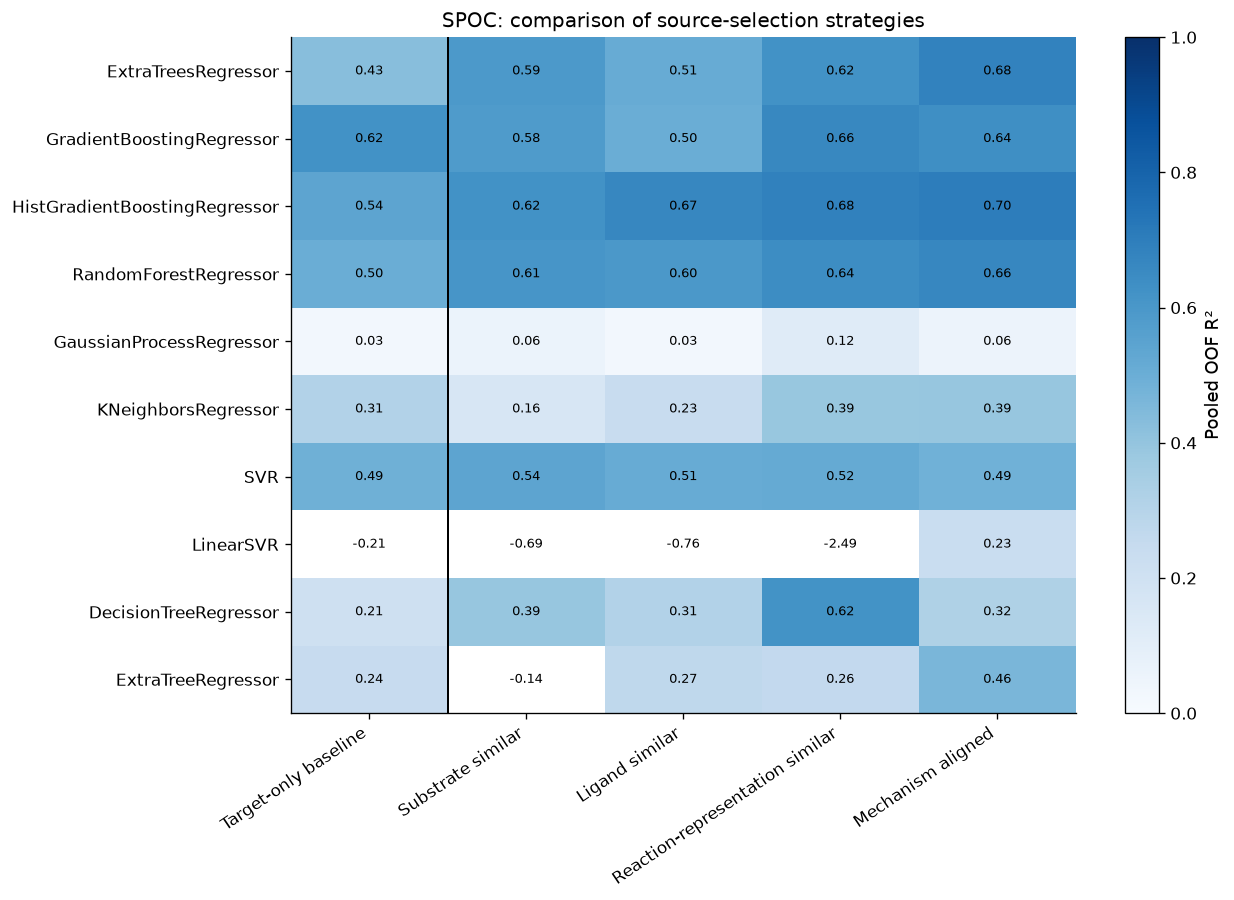

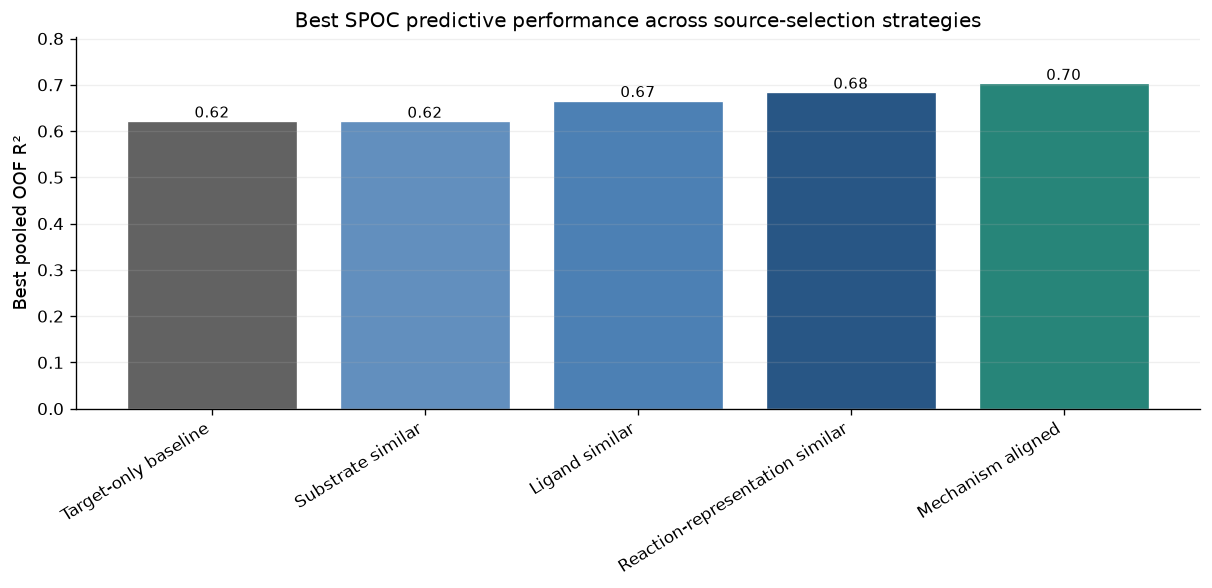

,source_rule_id,source_label,model,method_label,R2,MAE,RMSE
0,target_only,Target-only baseline,GradientBoostingRegressor,Target-only,0.621655,0.405804,0.581710
1,substrate_similar,Substrate similar,HistGradientBoostingRegressor,Delta learning,0.621104,0.441845,0.582133
2,ligand_similar,Ligand similar,HistGradientBoostingRegressor,Mixed transfer,0.665782,0.397161,0.546736
3,reaction_representation_similar,Reaction-representation similar,HistGradientBoostingRegressor,Mixed transfer,0.684017,0.389698,0.531612
4,mechanism_aligned,Mechanism aligned,HistGradientBoostingRegressor,Mixed transfer,0.702908,0.352521,0.515476


,source_rule_id,source_label,model,method_label,R2,MAE,RMSE,n_oof
0,substrate_similar,Substrate similar,HistGradientBoostingRegressor,Delta learning,0.621104,0.441845,0.582133,98
1,ligand_similar,Ligand similar,HistGradientBoostingRegressor,Mixed transfer,0.665782,0.397161,0.546736,98
2,reaction_representation_similar,Reaction-representation similar,HistGradientBoostingRegressor,Mixed transfer,0.684017,0.389698,0.531612,98
3,mechanism_aligned,Mechanism aligned,HistGradientBoostingRegressor,Mixed transfer,0.702908,0.352521,0.515476,98


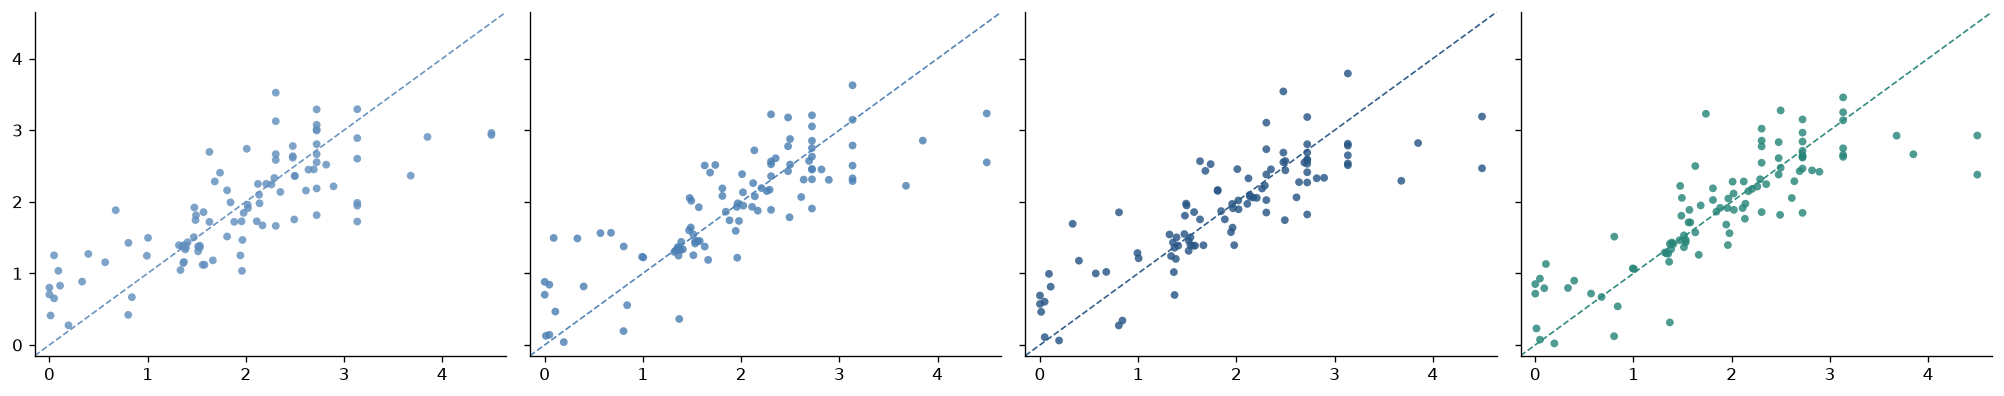

,source_rule_id,source_label,mean_overlap_with_mechanism_aligned
0,substrate_similar,Substrate similar,0.316768
1,ligand_similar,Ligand similar,0.640000
2,reaction_representation_similar,Reaction-representation similar,0.144242
3,mechanism_aligned,Mechanism aligned,1.000000


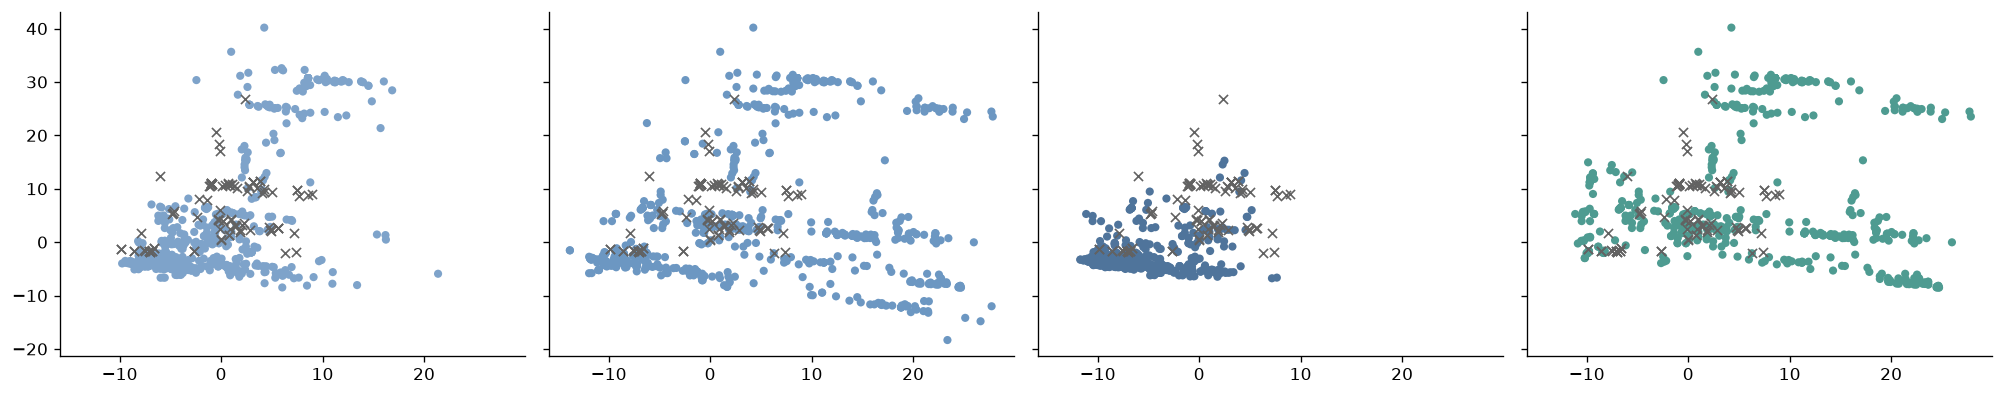

In [8]:
RULE_LABEL_MAP = {
    rule_id: rule["label"] for rule_id, rule in SOURCE_RULES.items()
}

# =========================
# 7.1 Absolute pooled OOF R² heatmap
# =========================
BASELINE_R2_SERIES = (
    BASELINE_METRICS.set_index("model")["baseline_R2"]
    .reindex(MODEL_KEYS_TO_RUN)
    .rename("Target-only baseline")
)

SELECTED_ABSOLUTE_R2 = (
    SELECTED_DF.pivot_table(
        index="model",
        columns="source_rule_id",
        values="R2",
        aggfunc="first",
        observed=True,
    )
    .reindex(index=MODEL_KEYS_TO_RUN)
    .reindex(columns=SOURCE_PLOT_ORDER)
)
SELECTED_ABSOLUTE_R2.columns = [
    RULE_LABEL_MAP[str(column)]
    for column in SELECTED_ABSOLUTE_R2.columns
]

ABSOLUTE_R2_HEATMAP = pd.concat(
    [BASELINE_R2_SERIES, SELECTED_ABSOLUTE_R2],
    axis=1,
)
ABSOLUTE_R2_HEATMAP.to_csv(
    TABLE_DIR
    / "spoc_selected_transfer_absolute_R2_model_by_source_rule.csv"
)

absolute_values = ABSOLUTE_R2_HEATMAP.to_numpy(dtype=float)

# Use the same fixed 0–1 color scale as the MACCS heatmap.
# Values below 0 are deliberately rendered in white rather than extending
# the color axis into the negative range.
absolute_cmap = plt.get_cmap("Blues").copy()
absolute_cmap.set_under("#FFFFFF")
absolute_cmap.set_bad("#FFFFFF")

fig_w = max(
    10.8,
    0.95 * ABSOLUTE_R2_HEATMAP.shape[1] + 3.0,
)
fig_h = max(
    4.5,
    0.58 * ABSOLUTE_R2_HEATMAP.shape[0] + 1.8,
)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
image = ax.imshow(
    absolute_values,
    aspect="auto",
    cmap=absolute_cmap,
    vmin=0.0,
    vmax=1.0,
)
ax.set_xticks(
    np.arange(ABSOLUTE_R2_HEATMAP.shape[1])
)
ax.set_xticklabels(
    ABSOLUTE_R2_HEATMAP.columns,
    rotation=34,
    ha="right",
)
ax.set_yticks(
    np.arange(ABSOLUTE_R2_HEATMAP.shape[0])
)
ax.set_yticklabels(
    ABSOLUTE_R2_HEATMAP.index
)
ax.axvline(
    0.5,
    color="black",
    linewidth=1.2,
)
ax.set_title(
    "SPOC: comparison of source-selection strategies"
)

for row_index in range(
    ABSOLUTE_R2_HEATMAP.shape[0]
):
    for column_index in range(
        ABSOLUTE_R2_HEATMAP.shape[1]
    ):
        value = ABSOLUTE_R2_HEATMAP.iloc[
            row_index,
            column_index,
        ]
        if pd.notna(value):
            ax.text(
                column_index,
                row_index,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color="black",
                fontweight="normal",
            )

colorbar = fig.colorbar(
    image,
    ax=ax,
    ticks=np.linspace(0.0, 1.0, 6),
)
colorbar.set_label("Pooled OOF R²")
fig.tight_layout()
fig.savefig(
    FIG_DIR
    / "spoc_selected_transfer_absolute_R2_source_rule_heatmap.svg",
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

# =========================
# 7.2 Best absolute pooled OOF R² for each source rule
# =========================
best_baseline_row = (
    BASELINE_METRICS.sort_values(
        ["baseline_R2", "baseline_MAE", "baseline_RMSE"],
        ascending=[False, True, True],
    )
    .iloc[0]
)

baseline_best = pd.DataFrame(
    [
        {
            "source_rule_id": "target_only",
            "source_label": "Target-only baseline",
            "model": best_baseline_row["model"],
            "method_label": "Target-only",
            "R2": float(best_baseline_row["baseline_R2"]),
            "MAE": float(best_baseline_row["baseline_MAE"]),
            "RMSE": float(best_baseline_row["baseline_RMSE"]),
        }
    ]
)

transfer_best = BEST_SOURCE_DF[
    [
        "source_rule_id",
        "source_label",
        "model",
        "method_label",
        "R2",
        "MAE",
        "RMSE",
    ]
].copy()
transfer_best["source_rule_id"] = (
    transfer_best["source_rule_id"]
    .astype(str)
)

BEST_R2_BY_SOURCE_RULE_DF = pd.concat(
    [baseline_best, transfer_best],
    ignore_index=True,
)

best_rule_order = [
    "target_only",
    *SOURCE_PLOT_ORDER,
]
BEST_R2_BY_SOURCE_RULE_DF[
    "source_rule_id"
] = pd.Categorical(
    BEST_R2_BY_SOURCE_RULE_DF["source_rule_id"],
    categories=best_rule_order,
    ordered=True,
)
BEST_R2_BY_SOURCE_RULE_DF = (
    BEST_R2_BY_SOURCE_RULE_DF.sort_values(
        "source_rule_id"
    )
    .reset_index(drop=True)
)
BEST_R2_BY_SOURCE_RULE_DF.to_csv(
    TABLE_DIR
    / "spoc_best_absolute_R2_by_source_rule.csv",
    index=False,
)

x = np.arange(
    len(BEST_R2_BY_SOURCE_RULE_DF)
)
values = BEST_R2_BY_SOURCE_RULE_DF[
    "R2"
].to_numpy(dtype=float)

fig, ax = plt.subplots(
    figsize=(
        max(
            10.2,
            1.05
            * len(BEST_R2_BY_SOURCE_RULE_DF),
        ),
        5.0,
    )
)
bar_colors = [
    SOURCE_RULE_COLORS[str(rule_id)]
    for rule_id in BEST_R2_BY_SOURCE_RULE_DF["source_rule_id"]
]
bars = ax.bar(
    x,
    values,
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8,
)

# Keep only the numerical best R² above each bar.
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_xticks(x)
ax.set_xticklabels(
    BEST_R2_BY_SOURCE_RULE_DF[
        "source_label"
    ],
    rotation=32,
    ha="right",
)
ax.set_ylabel("Best pooled OOF R²")
ax.set_title(
    "Best SPOC predictive performance across source-selection strategies"
)
ax.set_ylim(
    min(0.0, float(np.nanmin(values)) - 0.05),
    float(np.nanmax(values)) + 0.10,
)
ax.grid(
    axis="y",
    alpha=0.2,
)
fig.tight_layout()
fig.savefig(
    FIG_DIR
    / "spoc_best_absolute_R2_by_source_rule.svg",
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

display(BEST_R2_BY_SOURCE_RULE_DF)


# =========================
# 7.3 Pooled OOF parity plots for the four source-selection strategies
# =========================
PARITY_RULE_ORDER = list(SOURCE_PLOT_ORDER)

PARITY_TITLE_MAP = {
    "mechanism_aligned": "Mechanism-aligned transfer",
    "substrate_similar": "Substrate-similarity selection",
    "ligand_similar": "Ligand-similarity selection",
    "reaction_representation_similar": "Reaction-representation\nsimilarity selection",
}

parity_rows = []
parity_payload = {}

for rule_id in PARITY_RULE_ORDER:
    best_row = (
        BEST_SOURCE_DF.loc[
            BEST_SOURCE_DF["source_rule_id"].astype(str).eq(rule_id)
        ]
        .sort_values(
            ["R2", "MAE", "RMSE"],
            ascending=[False, True, True],
        )
        .iloc[0]
    )

    model_name = str(best_row["model"])
    method_label = str(best_row["method_label"])

    plot_df = OOF_DF.loc[
        OOF_DF["source_rule_id"].astype(str).eq(rule_id)
        & OOF_DF["model"].astype(str).eq(model_name)
        & OOF_DF["method_label"].astype(str).eq(method_label),
        ["fold_id", "target_index", "y_true", "y_pred"],
    ].copy()

    plot_df = plot_df.sort_values(
        ["target_index", "fold_id"]
    ).reset_index(drop=True)

    if len(plot_df) != len(DATASETS["ru_aho_inner"]):
        raise RuntimeError(
            f"Expected one pooled OOF prediction per Ru-AHO reaction for {rule_id}, "
            f"but found {len(plot_df)} rows."
        )

    parity_payload[rule_id] = {
        "best_row": best_row,
        "plot_df": plot_df,
    }

    parity_rows.append(
        {
            "source_rule_id": rule_id,
            "source_label": SOURCE_RULES[rule_id]["label"],
            "model": model_name,
            "method_label": method_label,
            "R2": float(best_row["R2"]),
            "MAE": float(best_row["MAE"]),
            "RMSE": float(best_row["RMSE"]),
            "n_oof": int(len(plot_df)),
        }
    )

PARITY_SUMMARY_DF = pd.DataFrame(parity_rows)
PARITY_SUMMARY_DF.to_csv(
    TABLE_DIR / "spoc_figure3_source_selection_parity_summary.csv",
    index=False,
)
display(PARITY_SUMMARY_DF)

all_parity_values = np.concatenate(
    [
        parity_payload[rule_id]["plot_df"][["y_true", "y_pred"]].to_numpy(dtype=float).ravel()
        for rule_id in PARITY_RULE_ORDER
    ]
)
finite_parity_values = all_parity_values[np.isfinite(all_parity_values)]
parity_min = min(-0.15, float(np.nanmin(finite_parity_values)) - 0.10)
parity_max = max(4.65, float(np.nanmax(finite_parity_values)) + 0.10)

fig, axes = plt.subplots(
    1,
    4,
    figsize=FIGURE3_PARITY_FIGSIZE,
    sharex=True,
    sharey=True,
)

for ax, rule_id in zip(axes, PARITY_RULE_ORDER):
    payload = parity_payload[rule_id]
    best_row = payload["best_row"]
    plot_df = payload["plot_df"]
    color = SOURCE_RULE_COLORS[rule_id]

    ax.scatter(
        plot_df["y_true"],
        plot_df["y_pred"],
        s=22,
        alpha=0.82,
        color=color,
        edgecolors="none",
    )
    ax.plot(
        [parity_min, parity_max],
        [parity_min, parity_max],
        linestyle="--",
        linewidth=1.0,
        color=color,
        alpha=0.95,
    )

    ax.set_xlim(parity_min, parity_max)
    ax.set_ylim(parity_min, parity_max)
    if SHOW_TEXT:
        ax.set_title(
            PARITY_TITLE_MAP[rule_id],
            color=color,
            fontweight="bold",
            fontsize=11,
        )
        ax.text(
            0.04,
            0.96,
            f"R² = {float(best_row['R2']):.2f}\n"
            f"MAE = {float(best_row['MAE']):.2f}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=10,
            fontweight="bold",
        )
        ax.set_xlabel("Observed ΔΔG‡ (kcal/mol)")
    else:
        ax.set_title("")
        ax.set_xlabel("")

if SHOW_TEXT:
    axes[0].set_ylabel("Predicted ΔΔG‡ (kcal/mol)")
    fig.suptitle(
        "SPOC: pooled OOF predictions under alternative source-selection strategies",
        y=1.02,
        fontsize=13,
    )
apply_figure_visibility(fig)
fig.tight_layout()
fig.savefig(
    FIG_DIR / "spoc_figure3_source_selection_parity_1x4.svg",
    bbox_inches="tight",
)
plt.show()
plt.close(fig)


# =========================
# 7.4 PCA maps of the source reactions selected by each strategy
# =========================
from matplotlib.colors import to_rgba

# PCA is visualization-only. A single common embedding is constructed from
# all processed Ru-AHK source candidates plus all Ru-AHO target reactions.
source_X = np.asarray(
    FEATURES["all_ru_ahk"],
    dtype=np.float32,
)
target_X = np.asarray(
    FEATURES["ru_aho_inner"],
    dtype=np.float32,
)

pca_input = np.vstack([source_X, target_X])
pca_imputer = make_median_imputer()
pca_input = pca_imputer.fit_transform(pca_input)
pca_input = np.nan_to_num(
    pca_input,
    nan=0.0,
    posinf=0.0,
    neginf=0.0,
)

pca_scaler = StandardScaler()
pca_scaled = pca_scaler.fit_transform(pca_input)
pca_scaled = np.nan_to_num(
    pca_scaled,
    nan=0.0,
    posinf=0.0,
    neginf=0.0,
)

pca_model = PCA(
    n_components=2,
    random_state=RANDOM_STATE,
)
pca_xy = pca_model.fit_transform(pca_scaled)

n_source_all = len(source_X)
source_xy = pca_xy[:n_source_all]
target_xy = pca_xy[n_source_all:]

selection_frequency = {
    rule_id: np.zeros(n_source_all, dtype=int)
    for rule_id in PARITY_RULE_ORDER
}

# The mechanism-aligned source is the inner-sphere portion of all Ru-AHK.
aligned_mask_all = (
    DATASETS["all_ru_ahk"]["_is_known_aligned"]
    .to_numpy(dtype=bool)
)
if int(aligned_mask_all.sum()) != int(N_ALIGNED):
    raise RuntimeError(
        "The number of aligned rows in all_ru_ahk does not match ru_ahk_inner. "
        f"Found {int(aligned_mask_all.sum())} vs {int(N_ALIGNED)}."
    )
selection_frequency["mechanism_aligned"][aligned_mask_all] = N_FOLDS

# Similarity rules are fold-local; count how often each Ru-AHK row is selected.
for rule_id in [
    "substrate_similar",
    "ligand_similar",
    "reaction_representation_similar",
]:
    for fold_id in range(1, N_FOLDS + 1):
        selected_indices = np.asarray(
            SOURCE_SELECTIONS[(rule_id, fold_id)],
            dtype=int,
        )
        selection_frequency[rule_id][selected_indices] += 1

# Save the common PCA coordinates and fold-selection frequencies for audit/use
# in the final Figure 3 assembly.
pca_source_table = pd.DataFrame(
    {
        "dataset": "Ru-AHK",
        "row_index": np.arange(n_source_all, dtype=int),
        "PC1": source_xy[:, 0],
        "PC2": source_xy[:, 1],
        "mechanism_aligned": aligned_mask_all.astype(int),
        "mechanism_aligned_selection_frequency": selection_frequency["mechanism_aligned"],
        "substrate_similarity_selection_frequency": selection_frequency["substrate_similar"],
        "ligand_similarity_selection_frequency": selection_frequency["ligand_similar"],
        "reaction_similarity_selection_frequency": selection_frequency["reaction_representation_similar"],
    }
)

pca_target_table = pd.DataFrame(
    {
        "dataset": "Ru-AHO",
        "row_index": np.arange(len(target_xy), dtype=int),
        "PC1": target_xy[:, 0],
        "PC2": target_xy[:, 1],
        "mechanism_aligned": np.nan,
        "mechanism_aligned_selection_frequency": np.nan,
        "substrate_similarity_selection_frequency": np.nan,
        "ligand_similarity_selection_frequency": np.nan,
        "reaction_similarity_selection_frequency": np.nan,
    }
)

PCA_SELECTION_EMBEDDING_DF = pd.concat(
    [pca_source_table, pca_target_table],
    ignore_index=True,
)
PCA_SELECTION_EMBEDDING_DF.to_csv(
    TABLE_DIR / "spoc_figure3_source_selection_pca_embedding.csv",
    index=False,
)

# Quantify how much each source-selection rule overlaps the mechanism-aligned
# source domain. For fold-local rules, report the mean fraction across folds.
overlap_rows = []
for rule_id in PARITY_RULE_ORDER:
    if rule_id == "mechanism_aligned":
        overlap_rate = 1.0
    else:
        overlap_rate = float(
            SOURCE_SELECTION_AUDIT.loc[
                SOURCE_SELECTION_AUDIT["source_rule_id"].astype(str).eq(rule_id),
                "aligned_overlap_rate",
            ].mean()
        )

    overlap_rows.append(
        {
            "source_rule_id": rule_id,
            "source_label": SOURCE_RULES[rule_id]["label"],
            "mean_overlap_with_mechanism_aligned": overlap_rate,
        }
    )

SOURCE_SELECTION_OVERLAP_DF = pd.DataFrame(overlap_rows)
SOURCE_SELECTION_OVERLAP_DF.to_csv(
    TABLE_DIR / "spoc_figure3_overlap_with_mechanism_aligned.csv",
    index=False,
)
display(SOURCE_SELECTION_OVERLAP_DF)

explained = 100.0 * pca_model.explained_variance_ratio_

fig, axes = plt.subplots(
    1,
    4,
    figsize=FIGURE3_PCA_FIGSIZE,
    sharex=True,
    sharey=True,
)

for ax, rule_id in zip(axes, PARITY_RULE_ORDER):
    color = SOURCE_RULE_COLORS[rule_id]
    freq = selection_frequency[rule_id]
    selected_mask = freq > 0

    # Display the union selected across folds with one consistent strategy color.
    # Frequencies remain available in PCA_SELECTION_EMBEDDING_DF.
    ax.scatter(
        source_xy[selected_mask, 0],
        source_xy[selected_mask, 1],
        s=PCA_SOURCE_POINT_SIZE,
        color=pca_source_color(rule_id),
        alpha=1.0,
        zorder=2,
        edgecolors="none",
        rasterized=True,
        label="Selected Ru-AHK",
    )

    # Ru-AHO target uses the dark gray, above the source points.
    ax.scatter(
        target_xy[:, 0],
        target_xy[:, 1],
        s=PCA_TARGET_POINT_SIZE,
        color=SOURCE_RULE_COLORS["target_only"],
        marker="x",
        linewidths=1.0,
        alpha=1.0,
        zorder=3,
        label="Ru-AHO target",
    )

    overlap_rate = float(
        SOURCE_SELECTION_OVERLAP_DF.loc[
            SOURCE_SELECTION_OVERLAP_DF["source_rule_id"].eq(rule_id),
            "mean_overlap_with_mechanism_aligned",
        ].iloc[0]
    )

    if SHOW_TEXT:
        ax.set_title(
            PARITY_TITLE_MAP[rule_id]
            + f"\nAligned-source overlap = {100.0 * overlap_rate:.1f}%",
            color=color,
            fontweight="bold",
            fontsize=10.5,
        )
        ax.set_xlabel(
            f"PC1 ({explained[0]:.1f}%)"
        )
    else:
        ax.set_title("")
        ax.set_xlabel("")
    ax.grid(False)

if SHOW_TEXT:
    axes[0].set_ylabel(f"PC2 ({explained[1]:.1f}%)")
    fig.suptitle(
        "SPOC: source-data selections in a common reaction-representation PCA space",
        y=1.02,
        fontsize=13,
    )

if SHOW_LEGEND:
    from matplotlib.lines import Line2D
    from matplotlib.legend_handler import HandlerTuple
    source_handles = tuple(
        Line2D([], [], marker="o", linestyle="none", markersize=6,
               markerfacecolor=pca_source_color(rule_id), markeredgecolor="none")
        for rule_id in PARITY_RULE_ORDER
    )
    target_handle = Line2D(
        [], [], marker="x", linestyle="none", markersize=7,
        color=SOURCE_RULE_COLORS["target_only"],
    )
    fig.legend(
        [source_handles, target_handle], ["Selected Ru-AHK", "Ru-AHO target"],
        handler_map={tuple: HandlerTuple(ndivide=None)}, handlelength=4.5,
        loc="lower center", ncol=2, frameon=False,
        bbox_to_anchor=(0.5, -0.035),
    )
apply_figure_visibility(fig)
fig.tight_layout(rect=(0, 0.07 if SHOW_LEGEND else 0, 1, 1))
fig.savefig(
    FIG_DIR / "spoc_figure3_source_selection_pca_1x4.svg",
    bbox_inches="tight",
)
plt.show()
plt.close(fig)
